In [2]:
import pandas as pd

In [29]:
violence_data = pd.read_excel("Violence Data.xlsx")

In [13]:
state_religion_data = pd.read_excel("state_religions.xlsx")

In [35]:
print(violence_data.head())
violence_data.shape

   country_id_cy   country_cy  year_cy region_cy          main_govt_name_cy  \
0            700  Afghanistan     1989      Asia  Government of Afghanistan   
1            700  Afghanistan     1990      Asia  Government of Afghanistan   
2            700  Afghanistan     1991      Asia  Government of Afghanistan   
3            700  Afghanistan     1992      Asia  Government of Afghanistan   
4            700  Afghanistan     1993      Asia  Government of Afghanistan   

   sb_exist_cy  sb_dyad_count_cy           sb_dyad_ids_cy  \
0            1                 5  724; 726; 727; 729; 732   
1            1                 5  724; 726; 727; 732; 733   
2            1                 4       724; 726; 727; 732   
3            1                 4       724; 726; 727; 732   
4            1                 4       726; 732; 734; 842   

                                    sb_dyad_names_cy  sb_deaths_parties_cy  \
0  Government of Afghanistan - Hizb-i Islami-yi A...                  1019   
1 

(6936, 74)

In [65]:
violence_data2 = violence_data[violence_data["sb_intrastate_exist_cy"] == 1]

violence_filtered = violence_data2[[
    "country_cy",
    "year_cy",
    "sb_intrastate_deaths_best_cy",
    "sb_intrastate_deaths_civilians_cy"
]]
violence_filtered.head()

,country_cy,year_cy,sb_intrastate_deaths_best_cy,sb_intrastate_deaths_civilians_cy
0,Afghanistan,1989,5174,303
1,Afghanistan,1990,1478,101
2,Afghanistan,1991,3302,38
3,Afghanistan,1992,4287,1687
4,Afghanistan,1993,4071,611


In [66]:
violence_filtered = violence_filtered.rename(columns={
    "country_cy": "country",
    "year_cy": "year",
    "sb_intrastate_deaths_best_cy": "intrastate_deaths",
    "sb_intrastate_deaths_civilians_cy": "civilian_deaths"
})
violence_filtered.head()

,country,year,intrastate_deaths,civilian_deaths
0,Afghanistan,1989,5174,303
1,Afghanistan,1990,1478,101
2,Afghanistan,1991,3302,38
3,Afghanistan,1992,4287,1687
4,Afghanistan,1993,4071,611


In [67]:
print(state_religion_data.head())
state_religion_data.shape
print(state_religion_data.columns)

   Unnamed: 0  ccode        cname  year  ccode_qog    cname_qog ccodealp  \
0          46    4.0  Afghanistan  1992          4  Afghanistan      AFG   
1          47    4.0  Afghanistan  1993          4  Afghanistan      AFG   
2          48    4.0  Afghanistan  1994          4  Afghanistan      AFG   
3          49    4.0  Afghanistan  1995          4  Afghanistan      AFG   
4          50    4.0  Afghanistan  1996          4  Afghanistan      AFG   

   ccodecow        cname_year ccodealp_year  biu_offrel  
0     700.0  Afghanistan 1992         AFG92           2  
1     700.0  Afghanistan 1993         AFG93           2  
2     700.0  Afghanistan 1994         AFG94           2  
3     700.0  Afghanistan 1995         AFG95           2  
4     700.0  Afghanistan 1996         AFG96           2  
Index(['Unnamed: 0', 'ccode', 'cname', 'year', 'ccode_qog', 'cname_qog',
       'ccodealp', 'ccodecow', 'cname_year', 'ccodealp_year', 'biu_offrel'],
      dtype='object')


In [87]:
religion_filtered = state_religion_data[[
    "cname",
    "biu_offrel"
]]
religion_filtered.head()

,cname,biu_offrel
0,Afghanistan,2
1,Afghanistan,2
2,Afghanistan,2
3,Afghanistan,2
4,Afghanistan,2


In [88]:
religion_filtered = religion_filtered.rename(columns={
    "cname": "country",
    "biu_offrel": "state-sponsored religion index"
})


,country,state-sponsored religion index
0,Afghanistan,2
1,Afghanistan,2
2,Afghanistan,2
3,Afghanistan,2
4,Afghanistan,2


In [102]:
religion_filtered2 = religion_filtered.drop_duplicates(
    subset=["country"]
)

religion_filtered2.head()

,country,state-sponsored religion index
0,Afghanistan,2
23,Albania,0
48,Algeria,2
73,Andorra,0
98,Angola,0


In [89]:
majority_data = pd.read_csv("religious_data.csv")
majority_data.head()

,Region,Country,Year,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,Level,Countrycode
0,World,All World,2010,NaN,8.982457,Very high,4.882030,30.584753,14.977995,0.198187,23.869791,2.195080,23.292166,3,900
1,World,All World,2020,NaN,8.966722,Very high,4.111001,28.771444,14.936468,0.187421,25.648489,2.183286,24.161890,3,900
2,Asia-Pacific,All Asia-Pacific,2010,NaN,8.804169,Very high,8.146677,6.138703,25.278584,0.004395,24.763258,2.649087,33.019299,2,90001
3,Asia-Pacific,All Asia-Pacific,2020,NaN,8.738061,Very high,6.955449,5.915316,25.671322,0.004072,26.132376,2.476142,32.845325,2,90001
4,Europe,All Europe,2010,NaN,4.724689,Moderate,0.271246,74.643921,0.222803,0.187239,5.295826,0.673520,18.705446,2,90002


In [90]:
majority_data2 = majority_data[majority_data["Year"] == 2020]
majority_data2 = majority_data2.rename(columns={
    "Country": "country"
})
majority_data3 = majority_data2.iloc[7:].copy()

majority_data3.head()

,Region,country,Year,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,Level,Countrycode
15,Asia-Pacific,Afghanistan,2020,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,1,4
17,Europe,Albania,2020,61.0,4.751494,Moderate,0.000158,17.815659,0.000708,0.010050,74.507225,0.013316,7.652888,1,8
19,Middle East-North Africa,Algeria,2020,182.0,0.372425,Very low,0.015001,0.294990,0.000000,0.000130,98.382347,0.041329,1.266207,1,12
21,Sub-Saharan Africa,Angola,2020,143.0,1.522381,Low,0.002393,93.044708,0.009274,0.001197,0.255656,0.571968,6.114808,1,24
23,Latin America-Caribbean,Argentina,2020,118.0,2.436827,Moderate,0.031062,88.453941,0.002574,0.384978,0.929196,0.965338,9.232909,1,32


In [108]:
religion_cols = [
    "Buddhists",
    "Christians",
    "Hindus",
    "Jews",
    "Muslims",
    "Other_Religions",
    "Religiously_Unaffiliated"
]

majority_data3["majority_religion"] = majority_data3[religion_cols].idxmax(axis=1)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [109]:
# year is 2020 for data

majority_filtered = majority_data3[[
    "Region",
    "country",
    "Diversity_rank",
    "RDI_score",
    "Diveristy_level",
    "Buddhists",
    "Christians",
    "Hindus",
    "Jews",
    "Muslims",
    "Other_Religions",
    "Religiously_Unaffiliated",
    "majority_religion"
]]

In [110]:
#to merge data together
final_data = violence_filtered.merge(
    religion_filtered2,
    on = ["country"],
    how = "left"
)
final_data.head()

,country,year,intrastate_deaths,civilian_deaths,state-sponsored religion index
0,Afghanistan,1989,5174,303,2.0
1,Afghanistan,1990,1478,101,2.0
2,Afghanistan,1991,3302,38,2.0
3,Afghanistan,1992,4287,1687,2.0
4,Afghanistan,1993,4071,611,2.0


In [111]:
final_data2 = final_data.merge(
    majority_filtered,
    on = ["country"],
    how = "left"
)
final_data2.head()

,country,year,intrastate_deaths,civilian_deaths,state-sponsored religion index,Region,Diversity_rank,RDI_score,Diveristy_level,Buddhists,Christians,Hindus,Jews,Muslims,Other_Religions,Religiously_Unaffiliated,majority_religion
0,Afghanistan,1989,5174,303,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
1,Afghanistan,1990,1478,101,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
2,Afghanistan,1991,3302,38,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
3,Afghanistan,1992,4287,1687,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims
4,Afghanistan,1993,4071,611,2.0,Asia-Pacific,200.0,0.032175,Very low,0.020001,0.019379,0.000128,0.000026,99.861969,0.090043,0.008457,Muslims


In [ ]:
df_final.to_csv("../data/cleaned_data.csv", index=False)

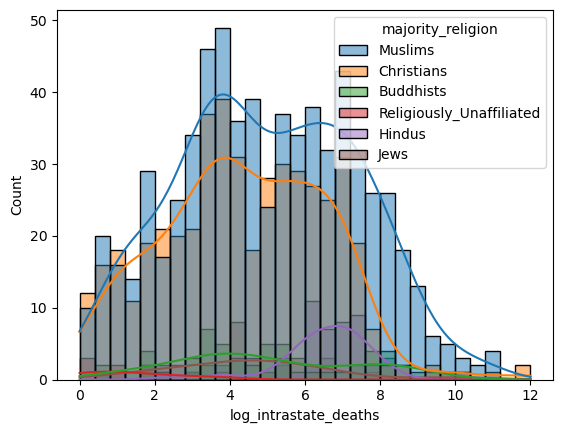

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.histplot(
    data=final_data2,
    x="log_intrastate_deaths",
    hue="majority_religion",
    bins=30,
    kde=True
)

plt.show()

In [131]:
region_conflict = (
    final_data2
    .groupby(
        ["Region", "state-sponsored religion index"]
    )["intrastate_deaths"]
    .mean()
    .reset_index()
)

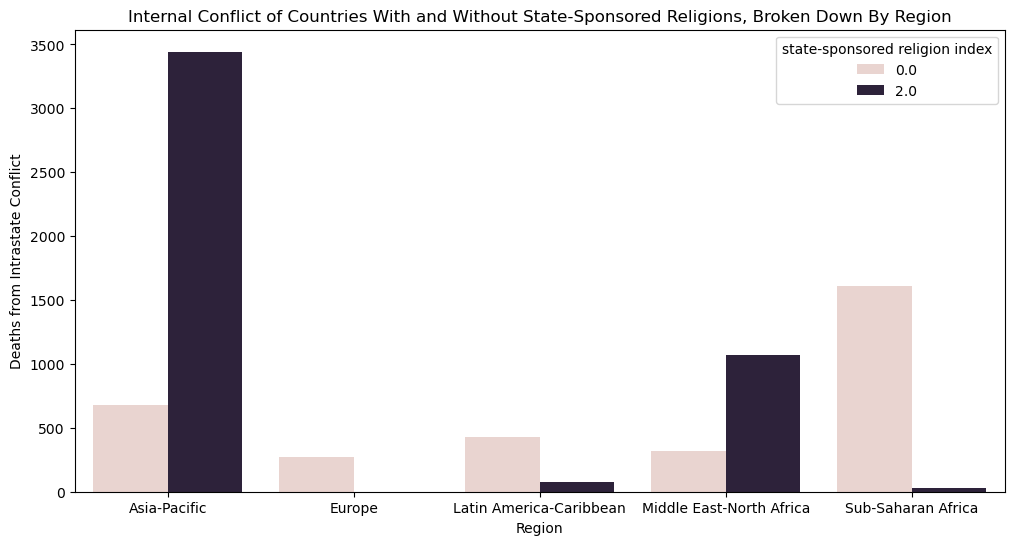

In [142]:
plt.figure(figsize=(12,6))

sns.barplot(
    data = region_conflict,
    x = "Region",
    y = "intrastate_deaths",
    hue = "state-sponsored religion index"
)

plt.xlabel("Region")
plt.ylabel("Deaths from Intrastate Conflict")
plt.title("Internal Conflict of Countries With and Without State-Sponsored Religions, Broken Down By Region")

plt.show()

In [ ]:
# potentially go into literature and do more
# with breakdown of religions and what makes
# up the different religions